<h2><center>Detect diabetic retinopathy to stop blindness before it's too late</center></h2>
<center><img src="https://raw.githubusercontent.com/dimitreOliveira/MachineLearning/master/Kaggle/APTOS%202019%20Blindness%20Detection/aux_img.png"></center>
##### Image source: http://cceyemd.com/diabetes-and-eye-exams/

In [2]:
# Helper libraries
import tensorflow
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
%matplotlib inline
print(tensorflow.__version__)

2.18.0


## Read in the training and test data

In [4]:
import os
import pandas as pd

# Đọc CSV nhãn
train_df = pd.read_csv('/kaggle/input/dataset/train_1.csv')

# Thư mục chứa ảnh
img_dir = '/kaggle/input/dataset/APTOS299/kaggle/working/all_images'

# Hàm tìm đúng file extension
def find_image_file(id_code):
    for ext in ['.png', '.jpeg', '.jpg']:
        path = os.path.join(img_dir, id_code + ext)
        if os.path.exists(path):
            return id_code + ext
    return None  # nếu không tìm thấy

# Tìm ảnh tương ứng và lọc bỏ ảnh không tồn tại
train_df['file_name'] = train_df['id_code'].apply(find_image_file)
train_df = train_df[train_df['file_name'].notnull()].reset_index(drop=True)


stage1_df = train_df.copy()

stage1_df['diagnosis'] = stage1_df['diagnosis'].astype(str)

print("Stage 1 label distribution:")
print(stage1_df['diagnosis'].value_counts())


# Số lớp mới và nhãn mô tả
num_classes = stage1_df['diagnosis'].nunique()
diag_text = ['Normal', 'Mild', 'Moderate', 'Severe','Proliferative']

print(f"Số lớp sau khi gộp: {num_classes}")
print(train_df.head())


Stage 1 label distribution:
diagnosis
0    1597
2     908
1     339
4     262
3     176
Name: count, dtype: int64
Số lớp sau khi gộp: 5
        id_code  diagnosis         file_name
0  1ae8c165fd53          2  1ae8c165fd53.png
1  1b329a127307          1  1b329a127307.png
2  1b32e1d775ea          4  1b32e1d775ea.png
3  1b3647865779          0  1b3647865779.png
4  1b398c0494d1          0  1b398c0494d1.png


In [5]:
# Lọc lớp 0
class0_df = stage1_df[stage1_df['diagnosis'] == "0"]

# Lấy ngẫu nhiên 1000 ảnh lớp 0 (nếu ít hơn thì lấy hết)
class0_sample = class0_df.sample(n=1000, random_state=42) if len(class0_df) >= 1100 else class0_df

# Giữ nguyên các lớp khác
other_classes_df = stage1_df[stage1_df['diagnosis'] != "0"]

# Ghép lại -> stage1_df mới
stage1_df = pd.concat([class0_sample, other_classes_df]).reset_index(drop=True)

print("Phân bố nhãn sau khi điều chỉnh:")
print(stage1_df['diagnosis'].value_counts())


Phân bố nhãn sau khi điều chỉnh:
diagnosis
0    1000
2     908
1     339
4     262
3     176
Name: count, dtype: int64


### Look at some raw images

### Graph out the class frequency

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(df, label_col="diagnosis", title="Class Frequency"):
    """
    Hiển thị số lượng ảnh theo từng nhãn trong dataframe.

    Args:
        df: pandas.DataFrame chứa dữ liệu
        label_col: tên cột chứa nhãn
        title: tiêu đề biểu đồ
    """
    unique, counts = np.unique(df[label_col], return_counts=True)
    
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c} images")

    plt.bar(unique, counts)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Frequency")
    plt.xticks(unique)  # đảm bảo hiển thị đúng nhãn
    plt.show()


Class 0: 1000 images
Class 1: 339 images
Class 2: 908 images
Class 3: 176 images
Class 4: 262 images


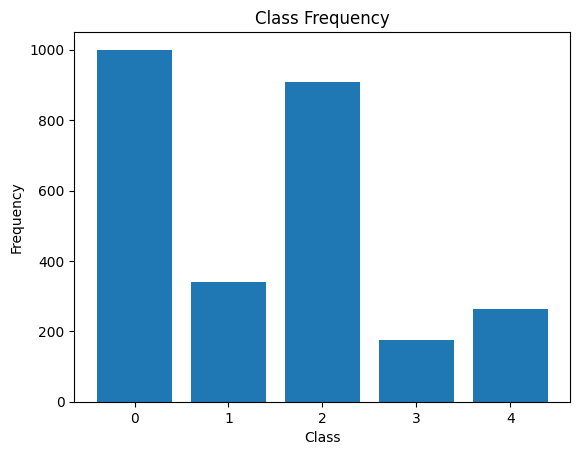

In [7]:
plot_class_distribution(stage1_df, label_col="diagnosis")

### Calculate class weights to help with training on the unbalanced data set.[](http://) 

In [8]:
from sklearn.utils import class_weight

classes = np.unique(stage1_df['diagnosis'])

sklearn_class_weights = class_weight.compute_class_weight(
    class_weight='balanced',   # ← tham số phải đặt tên
    classes=classes,
    y=stage1_df['diagnosis']
)

print(sklearn_class_weights)
class_weights_dict = dict(zip(classes, sklearn_class_weights))
print(class_weights_dict)


[0.537      1.5840708  0.59140969 3.05113636 2.04961832]
{'0': 0.537, '1': 1.584070796460177, '2': 0.5914096916299559, '3': 3.0511363636363638, '4': 2.049618320610687}


## Load a model

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D ,Concatenate
from tensorflow.keras.applications import DenseNet121, ResNet50, InceptionV3, Xception, ResNet50V2, EfficientNetB4,ResNet101
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras import layers, Model, Input
import tensorflow as tf

class CBAM(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.ratio = ratio
        self.channel_dense1 = None
        self.channel_dense2 = None
        self.spatial_conv = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')

    def build(self, input_shape):
        channel = input_shape[-1]
        self.channel_dense1 = layers.Dense(channel // self.ratio, activation='relu', kernel_initializer='he_normal')
        self.channel_dense2 = layers.Dense(channel, kernel_initializer='he_normal')
        super(CBAM, self).build(input_shape)

    def call(self, x):
        # Channel attention
        avg_pool = tf.reduce_mean(x, axis=[1,2], keepdims=True)
        max_pool = tf.reduce_max(x, axis=[1,2], keepdims=True)
        avg_out = self.channel_dense2(self.channel_dense1(avg_pool))
        max_out = self.channel_dense2(self.channel_dense1(max_pool))
        scale = tf.nn.sigmoid(avg_out + max_out)
        x = x * scale

        # Spatial attention
        avg_pool_spatial = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool_spatial = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool_spatial, max_pool_spatial], axis=-1)
        scale_spatial = self.spatial_conv(concat)
        x = x * scale_spatial
        return x

In [10]:

def create_resnet_effnet_cbam(input_shape, n_out):
    inputs = Input(shape=input_shape)

    # ResNet branch lấy feature map cuối cùng
    resnet_base = ResNet50(weights="imagenet", include_top=False, input_tensor=inputs)
    resnet_feat = resnet_base.get_layer("conv5_block3_out").output   # (7,7,2048)
    resnet_feat = CBAM(ratio=8)(resnet_feat)  # CBAM trên feature map

    # EfficientNet branch lấy feature map cuối cùng
    # effnet_base = EfficientNetB4(weights="imagenet", include_top=False, input_tensor=inputs)
    # effnet_feat = effnet_base.get_layer("top_conv").output           # (7,7,1792)
    # effnet_feat = CBAM(ratio=8)(effnet_feat)

    # # Gộp feature maps
    # concat = Concatenate()([resnet_feat, effnet_feat])   # (7,7,2048+1792)

    # Global pooling
    gap = GlobalAveragePooling2D()(resnet_feat)
    x = Dropout(0.5)(gap)
    x = Dense(2048, activation = 'relu')(x)
    x = Dropout(0.5)(x)
    # Classifier
    outputs = Dense(n_out, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model



In [9]:
def create_resnet50_model(input_shape, n_out):
    base_model = ResNet50(weights = "imagenet",
                          include_top = False,
                          input_shape = input_shape)
    
    model = Sequential()
    model.add(base_model)
    model.add(GlobalAveragePooling2D())
    model.add(Dropout(0.5))
    model.add(Dense(2048, activation = 'relu'))
    model.add(Dropout(0.5))    
    model.add(Dense(n_out, activation = 'softmax'))
    return model

In [19]:
IMAGE_HEIGHT = 299
IMAGE_WIDTH = 299
model = create_resnet_effnet_cbam(input_shape = (IMAGE_HEIGHT, IMAGE_WIDTH, 3), n_out = num_classes)

#### Crop and improve lighting condition using Ben Graham's preprocessing method
See: https://www.kaggle.com/ratthachat/aptos-updated-preprocessing-ben-s-cropping

### Look at some preprocessed images

### Change target to a multi-label problem so a class encompasses all the classes before it.
see: https://arxiv.org/abs/0704.1028

### Split into training and validation

In [12]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Chia dataframe thành train_df và val_df
train_df, val_df = train_test_split(stage1_df, test_size=0.2, stratify=stage1_df['diagnosis'], random_state=42)

# Generator cho train (có augment)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=90,
    horizontal_flip=True,
    zoom_range=[0.98, 1.02],
    width_shift_range=0.01,
    height_shift_range=0.01
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=img_dir,
    x_col='file_name',
    y_col='diagnosis',
    target_size=(299,299),
    class_mode='categorical',
    batch_size=16,
    shuffle=True
)

# Generator cho val (chỉ rescale, không augment)
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    directory=img_dir,
    x_col='file_name',
    y_col='diagnosis',
    target_size=(299,299),
    class_mode='categorical',
    batch_size=16,
    shuffle=False
)

Found 2148 validated image filenames belonging to 5 classes.
Found 537 validated image filenames belonging to 5 classes.


## Setup training data generator with augmentation

## Set up QWKOptimizerCheckpoint

In [13]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import cohen_kappa_score

# ==========================
# QWK Optimizer
# ==========================
class QWKOptimizer:
    def __init__(self, n_classes):
        self.n_classes = n_classes
        self.thresholds = None

    def _apply_thresholds(self, scores, thresholds):
        thresholds = np.sort(np.array(thresholds).ravel())  # ✅ ép thành 1D
        return np.digitize(scores, thresholds)

    def _qwk_loss(self, thresholds, scores, y_true):
        y_pred = self._apply_thresholds(scores, thresholds)
        return -cohen_kappa_score(y_true, y_pred, weights="quadratic")

    def fit(self, y_true, y_pred_proba):
        scores = (y_pred_proba * np.arange(self.n_classes)).sum(axis=1)
        init_thresholds = np.linspace(0, self.n_classes-1, self.n_classes-1)

        opt = minimize(
            self._qwk_loss,
            init_thresholds,
            args=(scores, y_true),
            method="Nelder-Mead",
            options={"maxiter": 100}
        )

        if opt.success:
            self.thresholds = np.sort(np.array(opt.x).ravel())
        else:
            # ✅ fallback: chia đều
            self.thresholds = np.linspace(0, self.n_classes-1, self.n_classes-1)

        return self

    def predict(self, y_pred_proba):
        scores = (y_pred_proba * np.arange(self.n_classes)).sum(axis=1)
        thresholds = np.sort(np.array(self.thresholds).ravel())  # ✅ đảm bảo luôn là 1D
        return np.digitize(scores, thresholds)


# ==========================
# QWK + Checkpoint Callback
# ==========================
class QWKOptimizerCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, val_generator, filepath="best_qwk.h5", n_classes=5, eval_interval=1):
        super().__init__()
        self.val_generator = val_generator
        self.filepath = filepath
        self.best_qwk = -np.inf
        self.n_classes = n_classes
        self.eval_interval = eval_interval

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.eval_interval != 0:
            return

        # Predict on validation
        val_pred_proba = self.model.predict(self.val_generator, verbose=0)
        val_true = self.val_generator.classes

        # Optimize thresholds (ở đây có thể mở rộng thêm grid-search)
        qwk_opt = QWKOptimizer(n_classes=self.n_classes).fit(val_true, val_pred_proba)
        val_pred = qwk_opt.predict(val_pred_proba)

        # Compute QWK
        qwk = cohen_kappa_score(val_true, val_pred, weights="quadratic")
        print(f"\nEpoch {epoch+1}: val_qwk = {qwk:.4f}")

        # Save model if better
        if qwk > self.best_qwk:
            self.best_qwk = qwk
            self.model.save(self.filepath)
            print(f"✔ Saved new best model with QWK = {qwk:.4f} at {self.filepath}")

        logs["val_qwk"] = qwk

            
qwk_cb = QWKOptimizerCheckpoint(val_generator)

In [20]:
import tensorflow as tf
from tensorflow.keras import backend as K
from scipy.optimize import minimize

WARMUP_EPOCHS = 3
WARMUP_LEARNING_RATE = 1e-3

class SoftmaxFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, name="softmax_focal_loss"):
        super().__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        """
        y_true: one-hot vector
        y_pred: softmax probabilities (after activation)
        """
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)  # tránh log(0)

        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = self.alpha * tf.pow(1 - y_pred, self.gamma)

        loss = tf.reduce_sum(focal_weight * cross_entropy, axis=1)
        return tf.reduce_mean(loss)

for layer in model.layers:
    layer.trainable = False

for layer in model.layers[-50:]:
    layer.trainable = True



model.compile(optimizer = Adam(learning_rate = WARMUP_LEARNING_RATE),
              loss = "categorical_crossentropy",  
              metrics = ['accuracy'])


checkpoint_ce = ModelCheckpoint(
    "stage1_best_original.h5", monitor="val_accuracy", save_best_only=True, mode="max"
)
early_ce = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

warmup_history = model.fit(train_generator,
                            class_weight = class_weights_dict,
                            steps_per_epoch = len(train_generator),
                            validation_data = val_generator,
                            epochs = WARMUP_EPOCHS, 
                            callbacks=[qwk_cb, checkpoint_ce, early_ce],
                            verbose = 1).history



for layer in model.layers:
    layer.trainable = True
    
model.compile(optimizer = Adam(learning_rate = 1e-4),
              loss="categorical_crossentropy",  
              metrics = ['accuracy'])

warmup_history = model.fit(train_generator,
                             class_weight = class_weights_dict,
                              steps_per_epoch = len(train_generator),
                              validation_data = val_generator,
                              epochs = 20, 
                                callbacks=[qwk_cb, checkpoint_ce, early_ce],
                              verbose = 1).history


Epoch 1/3
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.4616 - loss: 1.4201
Epoch 1: val_qwk = 0.0000
135/135 ━━━━━━━━━━━━━━━━━━━━ 103s 543ms/step - accuracy: 0.4620 - loss: 1.4191 - val_accuracy: 0.3724 - val_loss: 67.5530 - val_qwk: 0.0000e+00
Epoch 2/3
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.5710 - loss: 1.1944
Epoch 2: val_qwk = 0.5929
135/135 ━━━━━━━━━━━━━━━━━━━━ 50s 372ms/step - accuracy: 0.5711 - loss: 1.1943 - val_accuracy: 0.6089 - val_loss: 1.2608 - val_qwk: 0.5929
Epoch 3/3
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.6089 - loss: 1.1380
Epoch 3: val_qwk = 0.0000
135/135 ━━━━━━━━━━━━━━━━━━━━ 50s 367ms/step - accuracy: 0.6087 - loss: 1.1383 - val_accuracy: 0.3724 - val_loss: 89.9895 - val_qwk: 0.0000e+00
Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.4877 - loss: 1.4042
Epoch 1: val_qwk = 0.2229
135/135 ━━━━━━━━━━━━━━━━━━━━ 155s 643ms/step - accuracy: 0.4883 - loss: 1.4027 - val_accuracy: 0.3724 - val_loss: 10.1953 

In [17]:
FINETUNING_EPOCHS = 20
FINETUNING_LEARNING_RATE = 1e-4



# from tensorflow.keras.models import load_model
model = load_model(
    "/kaggle/working/best_qwk.h5",
    custom_objects={
        "CBAM": CBAM,                # layer custom
    },
    compile=False  # <-- tắt compile để tránh lỗi khi không cần train tiếp
)


import math
# Compile with lower LR


# Make all layers trainable
for layer in model.layers:
    layer.trainable = True
    
model.compile(
    optimizer = Adam(learning_rate = FINETUNING_LEARNING_RATE), 
    loss=WeightedKappaLoss(num_classes = 5),
    metrics = ['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    'blindness_detector_best.keras',   # ✅ đuôi .keras cho full model
    monitor='val_accuracy',
    save_best_only=True,      
    mode='max',
    verbose=1
)

rlrop = ReduceLROnPlateau(
    monitor = 'val_loss', 
    patience = 3, 
    factor = 0.5, 
    min_lr = 1e-6, 
    verbose = 1
)

stopping = EarlyStopping(
    monitor = 'val_accuracy', 
    patience = 8, 
    restore_best_weights = True, 
        mode='max',  
    verbose = 1
)

# ✅ Fix: Disable multiprocessing for stability on Windows
finetune_history = model.fit(
     train_generator,
    class_weight = class_weights_dict,
    steps_per_epoch = len(train_generator),
    validation_data = val_generator,
    epochs = FINETUNING_EPOCHS,
    callbacks = [qwk_cb, rlrop, stopping],         
    verbose = 1
).history
model.save("blindness_detector_best.keras")

Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.8200 - loss: 0.1255
Epoch 1: val_qwk = 0.8771
165/165 ━━━━━━━━━━━━━━━━━━━━ 165s 611ms/step - accuracy: 0.8201 - loss: 0.1254 - val_accuracy: 0.7199 - val_loss: 0.1455 - val_qwk: 0.8771 - learning_rate: 1.0000e-04
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7950 - loss: 0.1117
Epoch 2: val_qwk = 0.7817
165/165 ━━━━━━━━━━━━━━━━━━━━ 63s 384ms/step - accuracy: 0.7951 - loss: 0.1117 - val_accuracy: 0.6210 - val_loss: 0.2907 - val_qwk: 0.7817 - learning_rate: 1.0000e-04
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.8079 - loss: 0.1061
Epoch 3: val_qwk = 0.8757
165/165 ━━━━━━━━━━━━━━━━━━━━ 63s 382ms/step - accuracy: 0.8079 - loss: 0.1061 - val_accuracy: 0.7230 - val_loss: 0.1809 - val_qwk: 0.8757 - learning_rate: 1.0000e-04
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.7968 - loss: 0.1143
Epoch 4: val_qwk = 0.8728
165/165 ━━━━━━━━━━━━━━━━━━━━ 64s 389ms/step -

## Fine-tune the whole model

In [ ]:
# 3. CB-Focal Loss
# -------------------------------
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
from tensorflow.keras import backend as K
from scipy.optimize import minimize


# class_counts = np.array([1796 , 1069, 995, 1062 , 1003])
class_counts = np.array([1597 , 339, 908, 176 , 262])
boost_factors = [1, 1.8, 1, 2, 2]
# n_classes = 5
# class_counts = np.array([1069, 995, 1062 , 1003])
# boost_factors = [1, 1.2, 1.6, 1.6]

class CBFocalLoss(tf.keras.losses.Loss):
    def __init__(self, beta=0.9999, gamma=2.0, class_counts=None, boost_factors=None, name="cb_focal_loss"):
        """
        beta: hệ số cho class-balanced term (0.9999 hay dùng)
        gamma: hệ số Focal (2.0 thường tốt)
        class_counts: số mẫu của từng lớp (list hoặc np.array)
        boost_factors: list hệ số tăng weight cho từng lớp (vd [1,1,1,1.5,1.5] để tăng recall lớp 3,4)
        """
        super().__init__(name=name)
        self.beta = beta
        self.gamma = gamma

        # Tính weight cho từng lớp theo công thức Class-Balanced
        if class_counts is not None:
            effective_num = 1.0 - np.power(beta, class_counts)
            weights = (1.0 - beta) / np.array(effective_num)
            weights = weights / np.sum(weights) * len(class_counts)  # normalize
        else:
            weights = np.ones(len(class_counts)) if class_counts is not None else None

        # Nhân thêm boost factor nếu có
        if boost_factors is not None and weights is not None:
            weights = weights * np.array(boost_factors)

        self.class_weights = tf.constant(weights, dtype=tf.float32) if weights is not None else None

    def call(self, y_true, y_pred):
        """
        y_true: one-hot vector
        y_pred: softmax probabilities
        """
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)

        # cross entropy
        ce = -y_true * tf.math.log(y_pred)

        # focal term
        focal_weight = tf.pow(1 - y_pred, self.gamma)

        # class balanced weight
        if self.class_weights is not None:
            class_w = tf.reduce_sum(self.class_weights * y_true, axis=1)  # pick weight theo nhãn thật
            loss = class_w * tf.reduce_sum(focal_weight * ce, axis=1)
        else:
            loss = tf.reduce_sum(focal_weight * ce, axis=1)

        return tf.reduce_mean(loss)

loss_fn = CBFocalLoss(
    beta=0.9999,
    gamma=2.0,
    class_counts=class_counts,
    boost_factors=boost_factors
)

# -------------------------------
# 4. Build Phase 3 model
# -------------------------------
# model = load_model(
#     "/kaggle/working/best_qwk.h5",
#     custom_objects={"CBAM": CBAM},              # layer custom
#     compile=False  # <-- tắt compile để tránh lỗi khi không cần train tiếp
# )

model.compile(optimizer=Adam(1e-5), loss=loss_fn, metrics=["accuracy"])

# ------------------------------


# 6. Callbacks
# -------------------------------
early_cb = EarlyStopping(monitor="val_qwk", patience=7, restore_best_weights=True, verbose=1, mode="max")
ckpt_cb = ModelCheckpoint("blindness_detector_phase3_cbam.keras",
                          monitor="val_accuracy", save_best_only=True, verbose=1)
rlrop = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# -------------------------------
# 7. Warmup: train head
# -------------------------------
history_head = model.fit(
    train_generator,
    # class_weight = class_weights_dict,
    validation_data = val_generator,
    epochs=5,
    callbacks=[early_cb, qwk_cb, rlrop],
    verbose=1
)


model.compile(optimizer=Adam(5e-6), loss=WeightedKappaLoss(num_classes = 5), metrics=["accuracy"])

# -------------------------------
# 9. Fine-tune toàn block cuối
# -------------------------------
history_finetune = model.fit(
    train_generator,
    class_weight = class_weights_dict,
    validation_data = val_generator,
    epochs=10,
    callbacks=[early_cb,qwk_cb, rlrop],
    verbose=1
)

# -------------------------------
# 11. Save model Phase 3 + CBAM
# -------------------------------
model.save("blindness_detector_phase3_cb_cbam.keras")


In [21]:
from tensorflow.keras.layers import Layer
import tensorflow as tf

class CustomScaleLayer(Layer):
    def __init__(self, scale=1.0, **kwargs):
        super(CustomScaleLayer, self).__init__(**kwargs)
        self.scale = scale

    def call(self, inputs):
        # Nếu inputs là list/tuple thì cộng lại trước khi nhân
        if isinstance(inputs, (list, tuple)):
            x = tf.add_n(inputs)
        else:
            x = inputs
        return x * self.scale

    def compute_output_shape(self, input_shape):
        # Output shape giống với input shape
        if isinstance(input_shape, (list, tuple)):
            return input_shape[0]
        return input_shape

    def get_config(self):
        config = super().get_config()
        config.update({"scale": self.scale})
        return config


from tensorflow.keras.models import load_model
best_model = load_model(
    "/kaggle/working/best_qwk.h5",
    custom_objects={
        "CBAM": CBAM
        # "CustomScaleLayer": CustomScaleLayer,
    },
    compile=False
)


34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step
Optimized thresholds: [9.61e-04 1.28e+00 2.66e+00 3.79e+00]
Optimized QWK: 0.8803959289109772
               precision    recall  f1-score   support

       Normal       0.99      0.91      0.95       200
         Mild       0.55      0.59      0.57        68
     Moderate       0.75      0.64      0.69       182
       Severe       0.26      0.86      0.40        35
Proliferative       0.82      0.17      0.29        52

     accuracy                           0.70       537
    macro avg       0.67      0.63      0.58       537
 weighted avg       0.79      0.70      0.71       537

Confusion Matrix
[[0.91 0.09 0.01 0.   0.  ]
 [0.   0.59 0.38 0.03 0.  ]
 [0.01 0.08 0.64 0.27 0.  ]
 [0.   0.   0.09 0.86 0.06]
 [0.   0.02 0.15 0.65 0.17]]


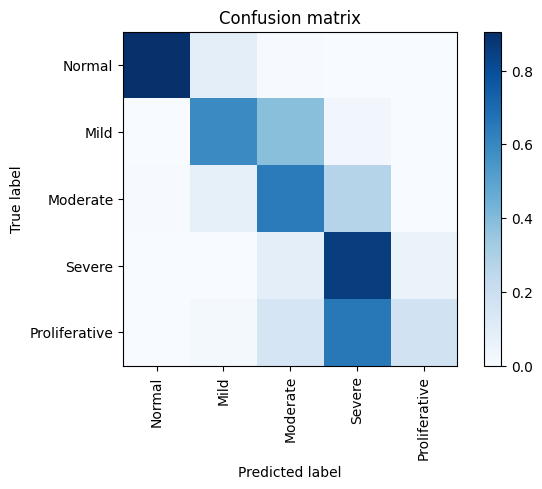

In [26]:
from scipy.optimize import minimize
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

def plot_confusion_matrix(cm, target_names, title = 'Confusion matrix', cmap = plt.cm.Blues):
    plt.grid(False)
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation = 90)
    plt.yticks(tick_marks, target_names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    
# Predict xác suất
y_pred_proba =best_model.predict(val_generator)
y_true = val_generator.classes  

# Optimize thresholds
qwk_opt = QWKOptimizer(n_classes=5).fit(y_true, y_pred_proba)

# Dự đoán
y_pred_opt = qwk_opt.predict(y_pred_proba)

# QWK
print("Optimized thresholds:", qwk_opt.thresholds)
print("Optimized QWK:",  cohen_kappa_score(y_true, y_pred_opt, weights="quadratic"))

# Classification Report
class_names = ["Normal", "Mild", "Moderate", "Severe","Proliferative"]

print(classification_report(y_true, y_pred_opt, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_opt)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("Confusion Matrix")
print(cm)
plot_confusion_matrix(cm = cm, target_names = diag_text)

In [ ]:
from tensorflow.keras.models import load_model
best_model = load_model(
    "/kaggle/working/blindness_detector_best.keras",
    custom_objects={
        "CBAM": CBAM,                # layer custom
        # "cb_focal_loss": CBFocalLoss  # loss custom
    },
    compile=False  # <-- tắt compile để tránh lỗi khi không cần train tiếp
)


34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step
Confusion Matrix AFTER PHASE 1
[[0.97 0.03 0.   0.   0.  ]
 [0.15 0.6  0.21 0.01 0.03]
 [0.02 0.14 0.57 0.19 0.08]
 [0.   0.   0.11 0.74 0.14]
 [0.   0.06 0.12 0.38 0.44]]
Classification Report
               precision    recall  f1-score   support

       Normal       0.94      0.97      0.95       200
         Mild       0.54      0.60      0.57        68
     Moderate       0.81      0.57      0.67       182
       Severe       0.32      0.74      0.44        35
Proliferative       0.51      0.44      0.47        52

     accuracy                           0.72       537
    macro avg       0.62      0.66      0.62       537
 weighted avg       0.76      0.72      0.73       537

Validation Cohen Kappa score: 0.860


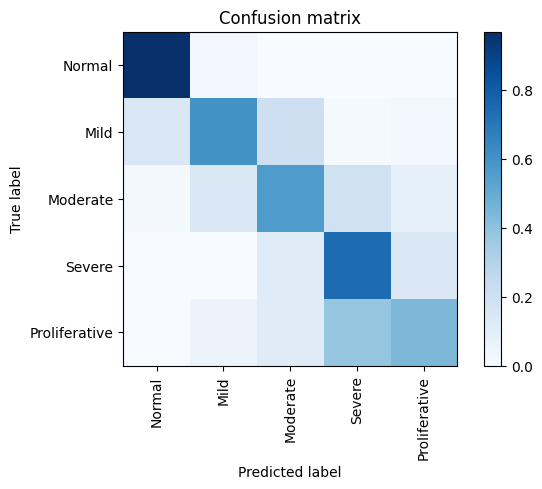

In [24]:
from scipy.optimize import minimize
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
# Xác suất dự đoán cho phase 1 2
# ---- DỰ ĐOÁN ----
validation_predictions_raw = best_model.predict(
    val_generator,
    steps = val_generator.n // val_generator.batch_size + 1,
    verbose = 1
)
diag_text = ['Normal', 'Mild', 'Moderate', 'Severe','Proliferative']

# Lấy class có xác suất cao nhất
validation_predictions = np.argmax(validation_predictions_raw, axis=1)

# ---- GROUND TRUTH ----
validation_truth = val_generator.classes   # nhãn thật


np.set_printoptions(precision = 2)
cm = confusion_matrix(validation_truth, validation_predictions)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# plot_confusion_matrix(cm = cm, target_names = diag_text)
# plt.show()

print('Confusion Matrix AFTER PHASE 1')
print(cm)

print('Classification Report')
print(classification_report(validation_truth, validation_predictions, target_names = diag_text))

print("Validation Cohen Kappa score: %.3f" % cohen_kappa_score(validation_predictions, validation_truth, weights = 'quadratic'))
plot_confusion_matrix(cm = cm, target_names = diag_text)

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step


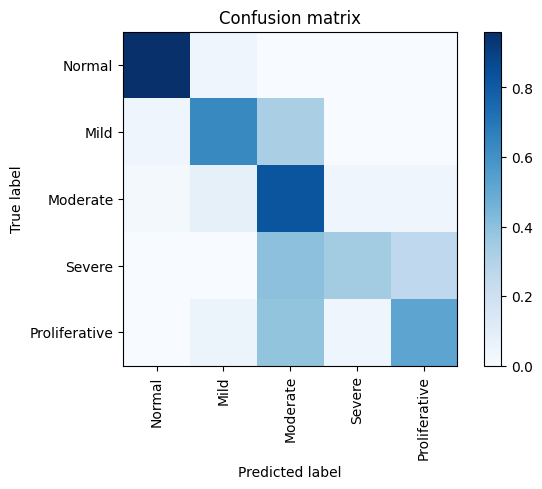

Confusion Matrix AFTER PHASE 1
[[0.96 0.04 0.   0.   0.  ]
 [0.04 0.63 0.32 0.   0.  ]
 [0.02 0.08 0.82 0.04 0.04]
 [0.   0.   0.4  0.34 0.26]
 [0.   0.06 0.38 0.04 0.52]]
Classification Report
               precision    recall  f1-score   support

       Normal       0.97      0.96      0.96       200
         Mild       0.62      0.63      0.63        68
     Moderate       0.73      0.82      0.77       182
       Severe       0.57      0.34      0.43        35
Proliferative       0.63      0.52      0.57        52

     accuracy                           0.79       537
    macro avg       0.70      0.66      0.67       537
 weighted avg       0.78      0.79      0.78       537

Validation Cohen Kappa score: 0.869


In [25]:
# Xác suất dự đoán cho phase 1 2
# ---- DỰ ĐOÁN ----
validation_predictions_raw = model.predict(
    val_generator,
    steps = val_generator.n // val_generator.batch_size + 1,
    verbose = 1
)
diag_text = ['Normal', 'Mild', 'Moderate', 'Severe','Proliferative']
# Lấy class có xác suất cao nhất
validation_predictions = np.argmax(validation_predictions_raw, axis=1)

# ---- GROUND TRUTH ----
validation_truth = val_generator.classes   # nhãn thật


np.set_printoptions(precision = 2)
cm = confusion_matrix(validation_truth, validation_predictions)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plot_confusion_matrix(cm = cm, target_names = diag_text)
plt.show()

print('Confusion Matrix AFTER PHASE 1')
print(cm)

print('Classification Report')
print(classification_report(validation_truth, validation_predictions, target_names = diag_text))

print("Validation Cohen Kappa score: %.3f" % cohen_kappa_score(validation_predictions, validation_truth, weights = 'quadratic'))

## Plot learning curves

## Evaluate the model

### Get validation predictions from the final model

### Plot some metrics

In [ ]:
from tensorflow import keras

# load model phase 1
model_phase2 = keras.models.load_model("/kaggle/working/blindness_detector_best.keras",  custom_objects={"CBAM": CBAM}, compile=False)

y_pred1  = best_model.predict(
    val_generator,
    steps = val_generator.n // val_generator.batch_size + 1,
    verbose = 1
)
y_pred2  = model.predict(
    val_generator,
    steps = val_generator.n // val_generator.batch_size + 1,
    verbose = 1
)
# nhãn thật
y_true = val_generator.classes   # (N,)


In [ ]:
best_score = -1
best_w1 = None

# thử grid search từ 0.0 -> 1.0 với step = 0.05
for w1 in np.arange(0, 1.05, 0.05):
    w2 = 1 - w1
    y_ensemble = w1 * y_pred1 + w2 * y_pred2
    
    y_pred_labels = np.argmax(y_ensemble, axis=1)
    
    # metric: cohen_kappa hoặc accuracy
    score = cohen_kappa_score(y_true, y_pred_labels)  
    
    if score > best_score:
        best_score = score
        best_w1 = w1

print(f"Best w1={best_w1:.2f}, w2={1-best_w1:.2f}, Cohen Kappa={best_score:.4f}")

y_final = best_w1 * y_pred1 + (1-best_w1) * y_pred2
y_final_labels = np.argmax(y_final, axis=1)

print(classification_report(y_true, y_final_labels))

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_meta = np.concatenate([y_pred1, y_pred2], axis=1)
y_meta = np.array(y_true)
if y_meta.ndim > 1:   # nếu one-hot
    y_meta = np.argmax(y_meta, axis=1)

oof_preds = np.zeros((len(y_meta), 5))  # 5 lớp

for train_idx, valid_idx in skf.split(X_meta, y_meta):
    X_train, X_valid = X_meta[train_idx], X_meta[valid_idx]
    y_train, y_valid = y_meta[train_idx], y_meta[valid_idx]

    clf = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05)
    clf.fit(X_train, y_train)

    oof_preds[valid_idx] = clf.predict_proba(X_valid)

oof_labels = np.argmax(oof_preds, axis=1)
print("Cohen Kappa (OOF):", cohen_kappa_score(y_meta, oof_labels))


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix

# y_val: true labels (5925,)
# p1_val, p2_val: softmax probs từ Phase1 & Phase2 (shape: [5925, 4])


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros((len(y_meta), 5))  # lưu dự đoán out-of-fold

y_meta = np.array(y_meta)
for train_idx, valid_idx in skf.split(X_meta, y_meta):
    X_train, X_valid = X_meta[train_idx], X_meta[valid_idx]
    y_train, y_valid = y_meta[train_idx], y_meta[valid_idx]
    
    # Train meta-classifier
    clf = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05)
    clf.fit(X_train, y_train)
    
    # Predict OOF
    oof_preds[valid_idx] = clf.predict_proba(X_valid)

# Sau khi xong 5-fold, oof_preds là OOF prediction cho toàn bộ validation
oof_labels = np.argmax(oof_preds, axis=1)

print("Cohen Kappa (OOF):", cohen_kappa_score(y_meta, oof_labels))
print(classification_report(y_meta, oof_labels))
print(confusion_matrix(y_meta, oof_labels))


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

def plot_confusion_matrix(cm, target_names, title = 'Confusion matrix', cmap = plt.cm.Blues):
    plt.grid(False)
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation = 90)
    plt.yticks(tick_marks, target_names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

np.set_printoptions(precision = 2)
cm = confusion_matrix(validation_truth, validation_predictions)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plot_confusion_matrix(cm = cm, target_names = diag_text)
plt.show()

print('Confusion Matrix AFTER PHASE 1')
print(cm)

print('Classification Report')
print(classification_report(validation_truth, validation_predictions, target_names = diag_text))

print("Validation Cohen Kappa score: %.3f" % cohen_kappa_score(validation_predictions, validation_truth, weights = 'quadratic'))

## Look at some predictions from the validation set

## Make some predictions 

### Preprocess the test images

In [28]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
# Kích thước resize mong muốn
IMAGE_HEIGHT = 299
IMAGE_WIDTH = 299

# Hàm crop ảnh (giữ lại vùng có nội dung)
def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:  # grayscale
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:  # RGB
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol        
        if mask.any():
            img1 = img[:,:,0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:,:,1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:,:,2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1,img2,img3], axis=-1)
        return img
    return img

# Hàm preprocess ảnh
def preprocess_image(image_path, sigmaX=10):
    image = cv2.imread(image_path)  # BGR
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # sang RGB ngay
    image = crop_image_from_gray(image)
    image = cv2.resize(image, (IMAGE_HEIGHT, IMAGE_WIDTH))
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigmaX), -4, 128)

    # split theo RGB luôn
    r, g, b = cv2.split(image)

    # CLAHE lên kênh G
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8,8))
    g_clahe = clahe.apply(g)

    # merge lại
    img_clahe = cv2.merge((r, g_clahe, b))
    return img_clahe  # vẫn RGB
    


def predict_single_image(model, image_path, thresholds, image_size=(IMAGE_HEIGHT,IMAGE_WIDTH)):
    # 1. Preprocess ảnh theo pipeline bạn đã viết
    img = preprocess_image(image_path)          # ảnh đã xử lý, RGB
    img = img.astype(np.float32) / 255.0        # normalize [0,1]
    x = np.expand_dims(img, axis=0)             # shape (1,H,W,3)

    # 2. Predict
    y_pred_proba = model.predict(x)             # shape (1, n_classes)

    # 3. Tính score liên tục
    n_classes = y_pred_proba.shape[1]
    scores = (y_pred_proba * np.arange(n_classes)).sum(axis=1)

    # 4. Apply thresholds để ra label
    y_pred = np.digitize(scores, thresholds)

    return y_pred[0], y_pred_proba[0]

In [40]:

src2 = "/kaggle/input/aptos2019/test_images/test_images"
dst = "/kaggle/working/all_images"

os.makedirs(dst, exist_ok=True)
for root, _, files in os.walk(src2):

    for file in tqdm(files, desc=f"Processing {os.path.basename(root)}"):
        src_path = os.path.join(root, file)
        dst_path = os.path.join(dst, file)
        img = preprocess_image(src_path)
        cv2.imwrite(dst_path, img)

print(f"Tổng số ảnh trong {dst}:", len(os.listdir(dst)))

Processing test_images: 100%|██████████| 366/366 [00:54<00:00,  6.65it/s]

Tổng số ảnh trong /kaggle/working/all_images: 366


In [ ]:
!zip -r /kaggle/working/all_images.zip /kaggle/working/all_images

In [ ]:
import os
import pandas as pd

valid_csv = pd.read_csv("/kaggle/input/aptos2019/test.csv")

# ==== Load model ====
optimized_thresholds = np.array([9.61e-04,1.28e+00,2.66e+00,3.79e+00])

# ==== Predict toàn bộ ====
y_true, y_pred = [], []

val_dir = "/kaggle/input/aptos2019/test_images/test_images"

for idx, row in valid_csv.iterrows():
    img_id = row["id_code"]
    true_label = row["diagnosis"]   # giữ ground-truth tách riêng

    img_path = os.path.join(val_dir, img_id + ".png")
    if not os.path.exists(img_path):
        continue

    # Dự đoán ảnh
    pred_label, proba = predict_single_image(best_model, img_path, optimized_thresholds)

    # Lưu kết quả
    y_true.append(true_label)
    y_pred.append(pred_label)


In [33]:

print("Optimized QWK:",  cohen_kappa_score(y_true, y_pred, weights="quadratic"))

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

Optimized QWK: 0.8517958616221469
              precision    recall  f1-score   support

           0       1.00      0.82      0.90       199
           1       0.24      0.40      0.30        30
           2       0.66      0.68      0.67        87
           3       0.17      0.47      0.25        17
           4       0.71      0.30      0.43        33

    accuracy                           0.69       366
   macro avg       0.55      0.53      0.51       366
weighted avg       0.79      0.69      0.72       366

[[163  31   3   2   0]
 [  0  12  16   2   0]
 [  0   6  59  20   2]
 [  0   1   6   8   2]
 [  0   1   6  16  10]]


In [ ]:
print("QWK:", cohen_kappa_score(y_true, y_pred, weights="quadratic"))
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

### Check out the class distribution in the predicitons compared to the traing data

In [ ]:
## COMPLETED